In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import UnivariateSpline
from braid_analysis import flymath
import pynumdiff

from align_course_direction_analysis import unifying_algo_analysis as uaa

import figurefirst as fifi

In [2]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

### Parameters

In [3]:
fname = '../../../../../Data/Animal_Trajectory_Data/d_melanogaster/d_mel_stillair_20220815_162329_5322_124.parquet'
df_raw = pd.read_parquet(fname)

df_raw = df_raw.dropna()

flow_direction = 0 + np.pi
flow_condition = 'stillair'
flow_speed = 0
body_length = 0.003
locomotion = 'flying'
medium = 'air'
group = 'aerial'

interp_dt = 0.01

### Get time stamps and speed -- this is custom per data type

In [4]:
df_calibrated = df_raw
df_calibrated['timestamps_sec'] = df_calibrated.time_relative_to_flash + 0.2

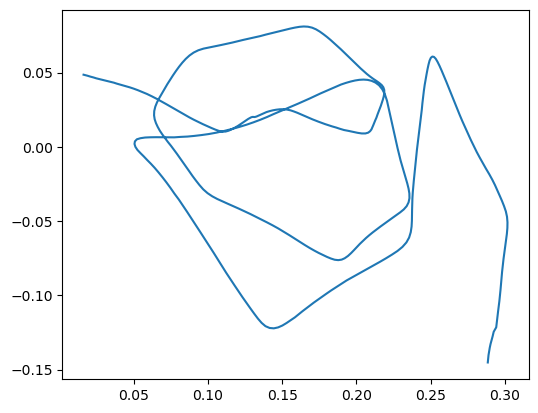

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.set_aspect('equal')

### Interpolate

In [6]:
interp_timestamps_sec = np.arange(0, df_calibrated.timestamps_sec.max(), interp_dt)

spline_x = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.x, s=1e-3, k=5)  # s=smoothing amount
interp_x = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.y, s=1e-3, k=5)  # s=smoothing amount
interp_y = spline_y(interp_timestamps_sec)

df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': interp_x,
                                     'y': interp_y})

### Parameters

In [7]:
df_calibrated_interp.shape

(453, 3)

In [8]:
tix_start = 120
tix_end = 452

1.2


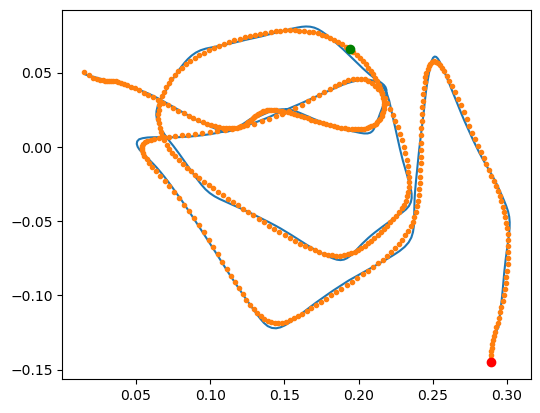

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

# when does search start
ax.plot(df_calibrated_interp.x.values[tix_start], df_calibrated_interp.y.values[tix_start], 'o', color='green')

# when does search end?
ax.plot(df_calibrated_interp.x.values[tix_end], df_calibrated_interp.y.values[tix_end], 'o', color='red')

print(df_calibrated_interp.timestamps_sec.values[tix_start])

ax.set_aspect('equal')

In [10]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [11]:
df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix_start]
df_calibrated_interp['obj_id_unique_event'] = fname.split('.')[0]
df_calibrated_interp['obj_id_unique'] = fname.split('.')[0]
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= flow_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

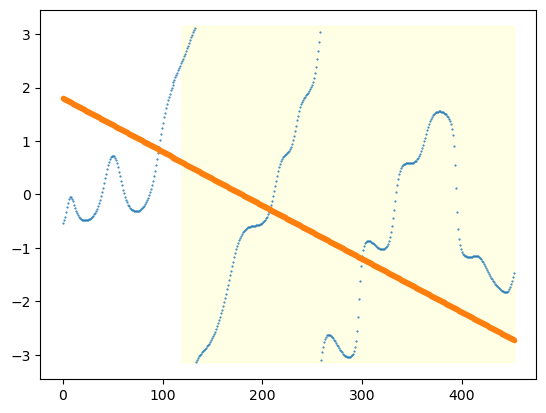

In [12]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.01
intercept=1.8
line = slope*ix + intercept

plt.fill_betweenx([-np.pi, np.pi], tix_start, tix_end, color='yellow', alpha=0.1)

plt.plot(ix, wrap_angle(line), '.')

### Parameters to set

In [13]:
min_ix_range = 190
max_ix_range = 200

In [14]:
trajec = df_calibrated_interp

In [15]:
course = trajec.course_smoothish.values
abs_min_ix = tix_start
abs_max_ix = tix_end

In [16]:
trajec['search_phase'] = np.zeros_like(trajec.x.values)
trajec.loc[tix_start:tix_end, 'search_phase']  = 1

trajec['flow_direction'] = [flow_direction]*len(trajec.x.values)
trajec['flow_condition'] = [flow_condition]*len(trajec.x.values)
trajec['flow_speed'] = [flow_speed]*len(trajec.x.values)
trajec['body_length'] = [body_length]*len(trajec.x.values)

trajec['locomotion'] = [locomotion]*len(trajec.x.values)
trajec['medium'] = [medium]*len(trajec.x.values)
trajec['group'] = [group]*len(trajec.x.values)

In [17]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = np.min([min_ix_range, 50]), 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0,
                                                  obj_id=trajec.obj_id_unique_event.values[0],
                                                  timestamps_sec=trajec.timestamps_sec,)

Restricted license - for non-production use only - expires 2027-11-29


SolverError: Solver 'GUROBI' failed. Try another solver, or solve with verbose=True for more information.

In [18]:
unifying_algo_fit['flow_direction'] = flow_direction
unifying_algo_fit['flow_condition'] = flow_condition
unifying_algo_fit['flow_speed'] = flow_speed
unifying_algo_fit['body_length'] = body_length

unifying_algo_fit['locomotion'] = locomotion
unifying_algo_fit['medium'] = medium
unifying_algo_fit['group'] = group



In [19]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [20]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,...,iteration,obj_id_unique_event,timestep_sec,flow_direction,flow_condition,flow_speed,body_length,locomotion,medium,group
4,131,322,0.046986,-3.278283,3.009686,1.072655,0.805175,1.068028,-0.034875,-0.034875,...,4,d_mel_stillair_20220815_162329_5322_124,0.01,3.141593,stillair,0,0.003,flying,air,aerial
5,146,337,0.047661,2.871069,2.958060,1.032497,0.817112,1.025323,-0.038648,-0.038648,...,5,d_mel_stillair_20220815_162329_5322_124,0.01,3.141593,stillair,0,0.003,flying,air,aerial
9,147,343,0.048036,-3.549280,2.937116,1.019554,0.835120,1.011950,-0.036670,-0.036670,...,9,d_mel_stillair_20220815_162329_5322_124,0.01,3.141593,stillair,0,0.003,flying,air,aerial
0,158,354,0.047506,-3.392680,2.990122,1.008524,0.846580,1.004837,-0.024156,-0.024156,...,0,d_mel_stillair_20220815_162329_5322_124,0.01,3.141593,stillair,0,0.003,flying,air,aerial
6,155,346,0.047190,-3.284168,3.035374,1.011170,0.836985,1.009212,-0.018363,-0.018363,...,6,d_mel_stillair_20220815_162329_5322_124,0.01,3.141593,stillair,0,0.003,flying,air,aerial
2,206,402,0.046367,-3.234605,-2.487205,0.946703,0.821261,0.900229,0.060581,0.060581,...,2,d_mel_stillair_20220815_162329_5322_124,0.01,3.141593,stillair,0,0.003,flying,air,aerial
8,222,412,0.046384,-3.088631,0.977228,0.994975,0.738840,0.818969,0.118757,0.118757,...,8,d_mel_stillair_20220815_162329_5322_124,0.01,3.141593,stillair,0,0.003,flying,air,aerial
7,243,438,0.047464,2.911994,1.304424,0.981732,0.683790,0.704435,0.075662,0.075662,...,7,d_mel_stillair_20220815_162329_5322_124,0.01,3.141593,stillair,0,0.003,flying,air,aerial
3,254,447,0.045172,-2.719152,1.116214,1.001174,0.562580,0.647140,0.173023,0.173023,...,3,d_mel_stillair_20220815_162329_5322_124,0.01,3.141593,stillair,0,0.003,flying,air,aerial
1,238,428,0.042379,4.321946,0.973334,1.012008,0.583492,0.719100,0.199300,0.199300,...,1,d_mel_stillair_20220815_162329_5322_124,0.01,3.141593,stillair,0,0.003,flying,air,aerial


In [21]:
ix_all, course, linear_fit_angle, affine_fit_angle, shift_ix_adj = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

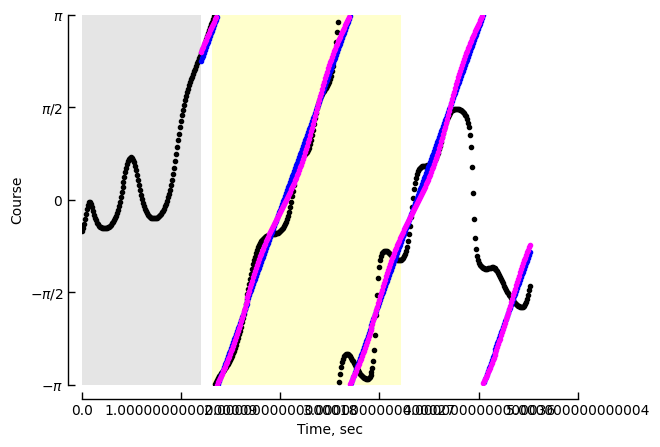

In [22]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [23]:
fname_trajec = fname.split('.')[0] + '_trajec.parquet'
trajec.to_parquet(fname_trajec)

unifying_algo_fit.to_parquet(fname.split('.')[0] + '_unifying_analysis.parquet')